In [22]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import xarray as xr 

In [23]:
data_1 =  "e:\\glider_data\\practice\\processing_1127_combind\\L0-gridfiles\\dfo-rosie713-20190615_grid.nc"     # slocum glider sample data
data_2 = "e:\\glider_data\\practice\\processing_1127_combind\\L0-timeseries\\dfo-rosie713-20190615.nc"         # slocum glider sample time series data
data_3 = "e:\\glider_data\\practice\\p6150001.nc"     # sea glider sample data

In [24]:
# Load the NetCDF datasetdata_file = data_1  # Choose which data file to use: data_1, data_2, or data_3
ds = xr.open_dataset(data_file)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# Basic overview of the dataset
ds

In [ ]:
# Dataset information
ds.info()

In [ ]:
# Dimensions
print('Dimensions:', ds.dims)

In [ ]:
# Coordinates
print('Coordinates:')
ds.coords

In [ ]:
# Data variables
print('Data variables:')
ds.data_vars

In [ ]:
# Global attributes
print('Global attributes:')
ds.attrs

In [ ]:
# Plot a sample variable
# Let's plot temperature if available
if 'temperature' in ds.data_vars:
    ds['temperature'].plot(figsize=(10, 6))
    plt.title('Temperature')
    plt.show()
elif 'temp' in ds.data_vars:
    ds['temp'].plot(figsize=(10, 6))
    plt.title('Temperature')
    plt.show()
else:
    print('Temperature variable not found. Available variables:', list(ds.data_vars.keys()))
    # Plot the first variable as example
    var = list(ds.data_vars.keys())[0]
    ds[var].plot(figsize=(10, 6))
    plt.title(f'Sample plot of {var}')
    plt.show()

In [ ]:
# Check for missing values
print('Missing values count:')
for var in ds.data_vars:
    nan_count = ds[var].isnull().sum().values
    print(f'{var}: {nan_count}')

In [ ]:
# Summary statistics for a key variable
if 'temperature' in ds.data_vars:
    print('Summary statistics for temperature:')
    print(ds['temperature'].to_series().describe())
elif 'temp' in ds.data_vars:
    print('Summary statistics for temp:')
    print(ds['temp'].to_series().describe())
else:
    var = list(ds.data_vars.keys())[0]
    print(f'Summary statistics for {var}:')
    print(ds[var].to_series().describe())

In [ ]:
# Time vs depth plot (if data contains both depth and time information)
# Prefer straightforward coordinate names when available
if 'time' in ds.coords:
    time_var = 'time'
elif 'time' in ds.data_vars:
    time_var = 'time'
else:
    time_var = next((k for k in ds.coords if 'time' in k.lower()), None)

if 'depth' in ds.coords:
    depth_var = 'depth'
elif 'depth' in ds.data_vars:
    depth_var = 'depth'
else:
    depth_var = next((k for k in ds.coords if 'depth' in k.lower()), None)

# Fallback candidates (keep them simple)
if time_var is None:
    time_var = next((k for k in ds.coords if 'time' in k.lower()), None)
if depth_var is None:
    depth_var = next((k for k in ds.coords if 'depth' in k.lower() or 'pressure' in k.lower()), None)

print('time_var:', time_var)
print('depth_var:', depth_var)

if time_var is not None and depth_var is not None:
    t = ds[time_var]
    z = ds[depth_var]

    # Convert to datetime if needed
    if np.issubdtype(t.dtype, np.number) and 'time' in time_var.lower():
        try:
            t = pd.to_datetime(t)
        except Exception:
            pass

    plt.figure(figsize=(12, 5))
    plt.plot(t, z, marker='.', linestyle='-', alpha=0.7)
    plt.gca().invert_yaxis()
    plt.xlabel(time_var)
    plt.ylabel(depth_var)
    plt.title(f"{depth_var} vs {time_var}")
    plt.tight_layout()
    plt.show()
else:
    print('Could not identify both time and depth variables. Falling back to a time series plot for temperature (or first variable).')
    if 'temperature' in ds.data_vars:
        ds['temperature'].plot(figsize=(12, 4))
        plt.title('Temperature time series')
    elif 'temp' in ds.data_vars:
        ds['temp'].plot(figsize=(12, 4))
        plt.title('Temperature time series')
    else:
        var = list(ds.data_vars.keys())[0]
        ds[var].plot(figsize=(12, 4))
        plt.title(f'Time series of {var}')
    plt.tight_layout()
    plt.show()

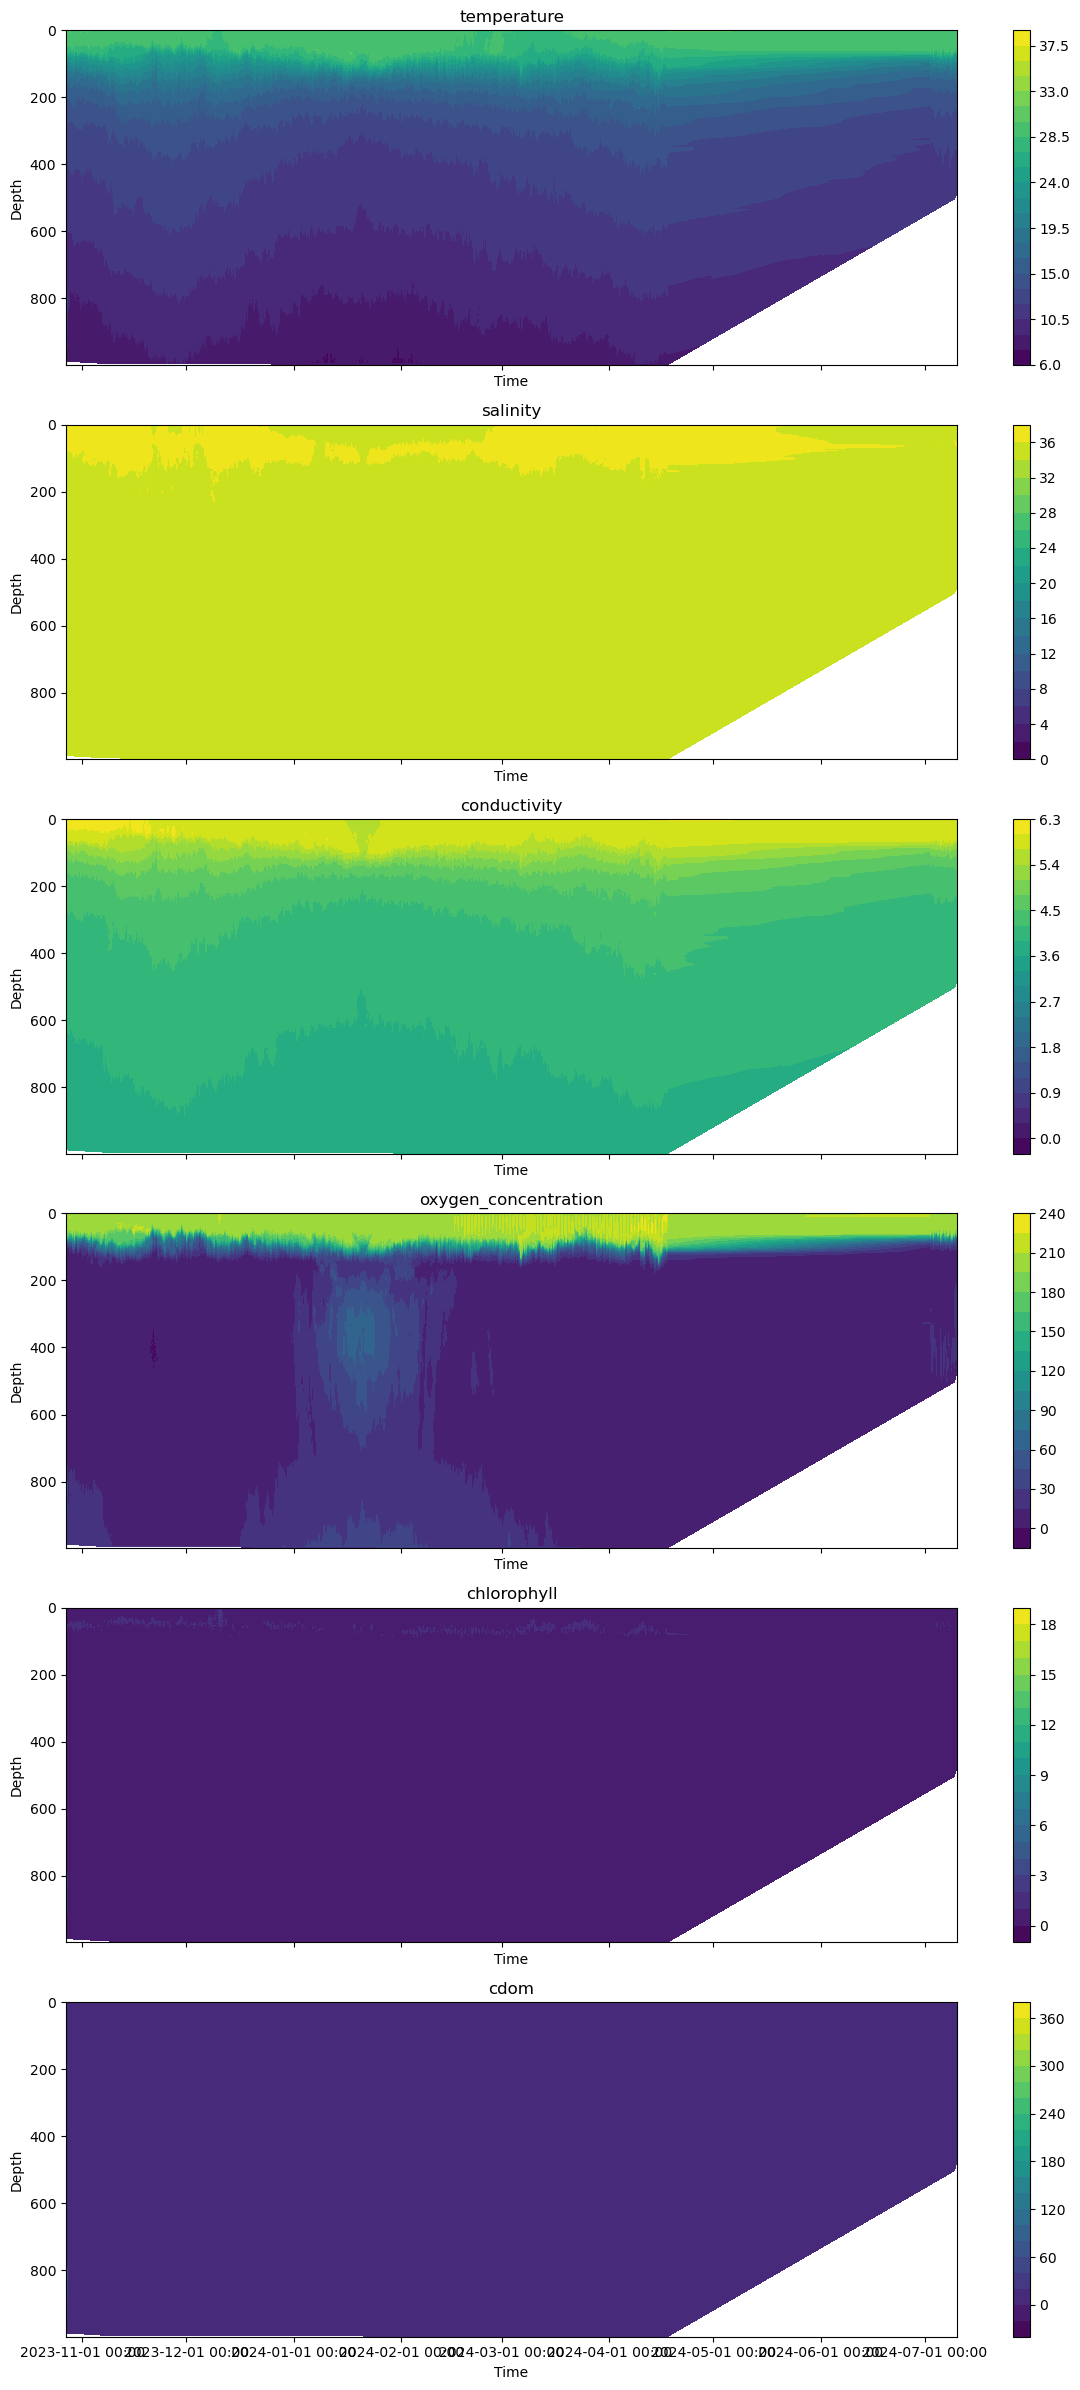

In [25]:
# Time-depth contour plots for key variables
preferred_vars = ['temperature', 'salinity', 'conductivity', 'oxygen_concentration', 'chlorophyll', 'cdom', 'backscatter_700', 'density', 'potential_temperature']
vars_to_plot = [v for v in preferred_vars if v in ds.data_vars] or list(ds.data_vars)[:6]

import matplotlib.dates as mdates
n = min(len(vars_to_plot), 6)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 4 * n), sharex=True)
if n == 1: axes = [axes]

for ax, var in zip(axes, vars_to_plot[:n]):
    try:
        if 'depth' in ds.dims and 'time' in ds.dims:
            ds[var].plot.contourf(x='time', y='depth', ax=ax, levels=20, cmap='viridis', add_colorbar=True)
        else:
            time, depth, value = ds['time'].values, ds['depth'].values, ds[var].values
            mask = ~np.isnan(value) & ~np.isnan(depth)
            time_m, depth_m, value_m = time[mask], depth[mask], value[mask]
            time_plot = mdates.date2num(pd.to_datetime(time_m)) if pd.api.types.is_datetime64_any_dtype(time_m) else time_m
            tri = Triangulation(time_plot, depth_m)
            cs = ax.tricontourf(tri, value_m, levels=20, cmap='viridis')
            plt.colorbar(cs, ax=ax)
            if pd.api.types.is_datetime64_any_dtype(time_m):
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
                ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.invert_yaxis()
        ax.set_title(var)
        ax.set_xlabel('Time')
        ax.set_ylabel('Depth')
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()